<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/lab4aml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import os

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

image_size = 32
batch_size = 64
nz = 100
num_epochs = 5

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Downloading CIFAR-10...")
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

num_classes = len(dataset.classes)
print(f"Dataset successfully loaded. Classes: {dataset.classes} ({num_classes} total)")

Using device: cuda:0
Dataset successfully loaded. Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] (10 total)


# VAE Implementation (task 1)

In [11]:
class VAE(nn.Module):
  def __init__(self):
    super(VAE, self).__init__()
    self.encoder = nn.Sequential(
        nn.Flatten(),
        nn.Linear(3*32*32, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU()
    )
    self.fc_mu = nn.Linear(512, nz)
    self.fc_logvar = nn.Linear(512, nz)

    self.decoder = nn.Sequential(
        nn.Linear(nz, 512),
        nn.ReLU(),
        nn.Linear(512, 1024),
        nn.ReLU(),
        nn.Linear(1024, 3*32*32),
        nn.Tanh()
    )

  def encode(self, x):
    h = self.encoder(x)
    return self.fc_mu(h), self.fc_logvar(h)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    return self.decoder(z).view(-1, 3, 32, 32)

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    return self.decode(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
  MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return MSE + KLD

cVAE Implementation (task 2)

In [12]:
class cVAE(nn.Module):
  def __init__(self, n_classes):
    super(cVAE, self).__init__()
    self.label_emb = nn.Embedding(n_classes, 50)
    self.label_transform_enc = nn.Linear(50, 3*32*32)
    self.label_transform_dec = nn.Linear(50, nz)

    self.encoder = nn.Sequential(
        nn.Linear(3*32*32 * 2, 512),
        nn.ReLU()
    )

    self.fc_mu = nn.Linear(512, nz)
    self.fc_logvar = nn.Linear(512, nz)

    self.decoder = nn.Sequential(
        nn.Linear(nz * 2, 512),
        nn.ReLU(),
        nn.Linear(512, 3*32*32),
        nn.Tanh()
    )

  def encode(self, x, labels):
    x_flat = x.view(-1, 3*32*32)
    y_emb = self.label_emb(labels)
    y_transformed = self.label_transform_enc(y_emb)
    inputs = torch.cat([x_flat, y_transformed], dim=1)
    h = self.encoder(inputs)
    return self.fc_mu(h), self.fc_logvar(h)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z, labels):
    y_emb = self.label_emb(labels)
    y_transformed = self.label_transform_dec(y_emb)
    inputs = torch.cat([z, y_transformed], dim=1)
    return self.decoder(inputs).view(-1, 3, 32, 32)

  def forward(self, x, labels):
    mu, logvar = self.encode(x, labels)
    z = self.reparameterize(mu, logvar)
    return self.decode(z, labels), mu, logvar

# DCGAN Implementation (task 3)

In [13]:
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()
    self.main = nn.Sequential(
        nn.ConvTranspose2d(nz, 256, 4, 1, 0, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
        nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
        nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True),
        nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False), nn.Tanh()
    )
  def forward(self, input): return self.main(input)

class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.main = nn.Sequential(
        nn.Conv2d(3, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(256, 1, 4, 1, 0, bias=False), nn.Sigmoid()
        )
  def forward(self, input): return self.main(input).view(-1)

# Training Loop

In [7]:
vae = VAE().to(device)
cvae = cVAE(num_classes).to(device)
netG = Generator().to(device)
netD = Discriminator().to(device)

opt_vae = optim.Adam(vae.parameters(), lr=1e-4)
opt_cvae = optim.Adam(cvae.parameters(), lr=1e-4)
optG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion = nn.BCELoss()

print("Training models...")
for epoch in range(num_epochs):
  for data, labels_raw in dataloader:
    data = data.to(device)
    labels = labels_raw.to(device)
    b_size = data.size(0)

    opt_vae.zero_grad()
    recon_vae, mu_vae, logvar_vae = vae(data)
    l_vae = vae_loss(recon_vae, data, mu_vae, logvar_vae)
    l_vae.backward()
    opt_vae.step()

    opt_cvae.zero_grad()
    recon_cvae, mu_cvae, logvar_cvae = cvae(data, labels)
    l_cvae = vae_loss(recon_cvae, data, mu_cvae, logvar_cvae)
    l_cvae.backward()
    opt_cvae.step()

    netD.zero_grad()
    label = torch.full((b_size,), 1.0, device=device)
    output = netD(data)
    errD_real = criterion(output, label)
    errD_real.backward()

    noise = torch.randn(b_size, nz, 1, 1, device=device)
    fake = netG(noise)
    label.fill_(0.0)
    output = netD(fake.detach())
    errD_fake = criterion(output, label)
    errD_fake.backward()
    optD.step()

    netG.zero_grad()
    label.fill_(1.0)
    output = netD(fake)
    errG = criterion(output, label)
    errG.backward()
    optG.step()

  print(f"Epoch {epoch+1}/{num_epochs} | VAE Loss: {l_vae.item():.2f} | cVAE Loss: {l_cvae.item():.2f}")

Training models...
Epoch 1/5 | VAE Loss: 5633.01 | cVAE Loss: 5108.54
Epoch 2/5 | VAE Loss: 3755.66 | cVAE Loss: 3584.36
Epoch 3/5 | VAE Loss: 3479.69 | cVAE Loss: 3261.94
Epoch 4/5 | VAE Loss: 3304.70 | cVAE Loss: 3085.62
Epoch 5/5 | VAE Loss: 4162.34 | cVAE Loss: 3970.07


# Visualizations

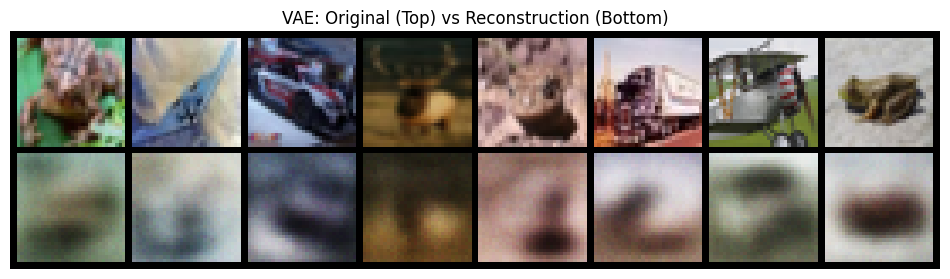

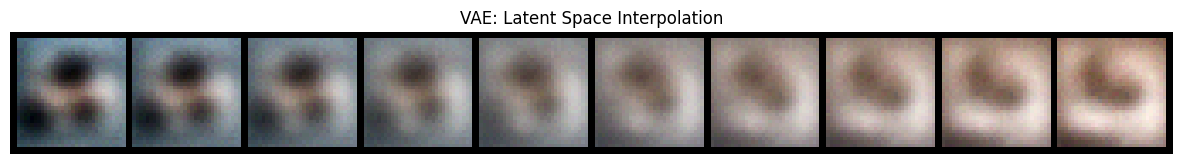

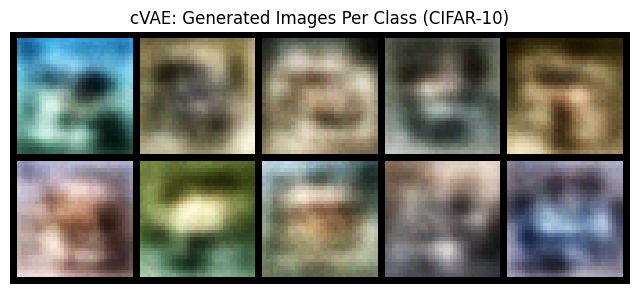

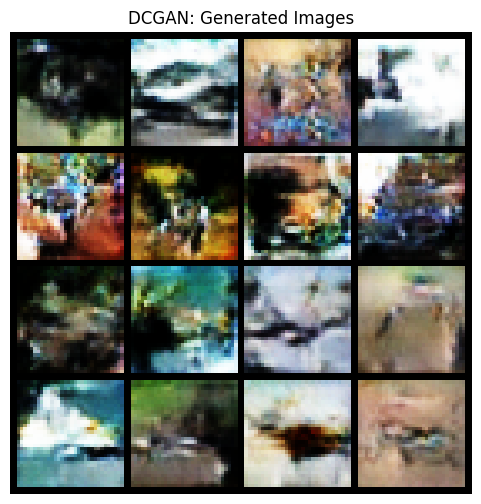

In [8]:
vae.eval()
cvae.eval()
netG.eval()

sample_batch = next(iter(dataloader))[0][:8].to(device)
with torch.no_grad():
  recon, _, _ = vae(sample_batch)
grid_recon = vutils.make_grid(torch.cat([sample_batch.cpu(), recon.cpu()]), nrow=8, normalize=True)
plt.figure(figsize=(12,4))
plt.imshow(np.transpose(grid_recon.numpy(), (1,2,0)))
plt.title("VAE: Original (Top) vs Reconstruction (Bottom)")
plt.axis('off')
plt.show()

with torch.no_grad():
  z1, z2 = torch.randn(1, nz).to(device), torch.randn(1, nz).to(device)
  alphas = np.linspace(0, 1, 10)
  imgs = []
  for a in alphas:
    z_interp = z1 * (1 - a) + z2 * a
    imgs.append(vae.decode(z_interp))
  grid_interp = vutils.make_grid(torch.cat(imgs), nrow=10, normalize=True)
plt.figure(figsize=(15,3))
plt.imshow(np.transpose(grid_interp.cpu().numpy(), (1,2,0)))
plt.title("VAE: Latent Space Interpolation")
plt.axis('off')
plt.show()

with torch.no_grad():
  z = torch.randn(num_classes, nz).to(device)
  labels = torch.arange(num_classes).to(device)
  samples = cvae.decode(z, labels)
grid_cvae = vutils.make_grid(samples, normalize=True, nrow=5)
plt.figure(figsize=(8,4))
plt.imshow(np.transpose(grid_cvae.cpu().numpy(), (1,2,0)))
plt.title("cVAE: Generated Images Per Class (CIFAR-10)")
plt.axis('off')
plt.show()

with torch.no_grad():
  noise = torch.randn(16, nz, 1, 1, device=device)
  fake_imgs = netG(noise)
grid_gan = vutils.make_grid(fake_imgs, normalize=True, nrow=4)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_gan.cpu().numpy(), (1,2,0)))
plt.title("DCGAN: Generated Images")
plt.axis('off')
plt.show()